# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs, DataGenerationProcess
import core.rct as rct
from core.variables import *
from core.utils import *

# DGP

In [6]:
# bernoulli specification
# dgp_params = {
#     'n_experiments': 100, 
#     'base_effects': [PointMass(0.1), PointMass(0.11)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

# # continuous specification
# dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(1), PointMass(1.1)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'dgp_seed': 0
# }

# logit specification
dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'logit', 
    'dgp_seed': 0
}

dgp = RCTs(**dgp_params)

In [7]:
samples = dgp.sample(sample_size=1000, seed=0)

# Estimation

In [8]:
emp_te_arr, emp_var_arr = rct.estimate_treatment_effects(samples, response_type=dgp.response_type)

# Selection

In [9]:
selection = rct.select_higher_effect(treatment_effects=emp_te_arr, treatment_vars=emp_var_arr)

# Evaluation

In [10]:
val_est = rct.obj_func(selection=selection, treatment_effects=emp_te_arr)
val_true = rct.obj_func(selection=selection, treatment_effects=dgp.treatment_effects)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,0.188557
True Policy Value,0.100000
Winner's Curse,0.088557


In [11]:
del dgp, samples, emp_te_arr, selection, val_est, val_true, result_df

# Winner's Curse

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.8s finished


In [13]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.6f} ({val_true_se:.6f})')
    print(f'  - Average Estimated Value: {val_est_avg:.6f} ({val_est_se:.6f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.4%} ({wc_se/delta_tau:.4%})')


Selection with Rank and Select:
  - Average True Value: 1.076400 (0.004246)
  - Average Estimated Value: 1.119553 (0.008759)
  - Average Winner's Curse (%): 43.1531% (9.0972%)


# Estimating Winner's Curse

In [14]:
dgp = RCTs(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [15]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type,
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.2s finished


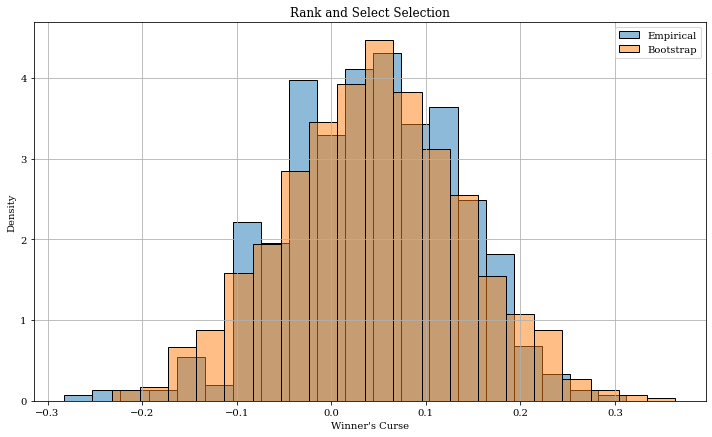

In [16]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [18]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type,
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


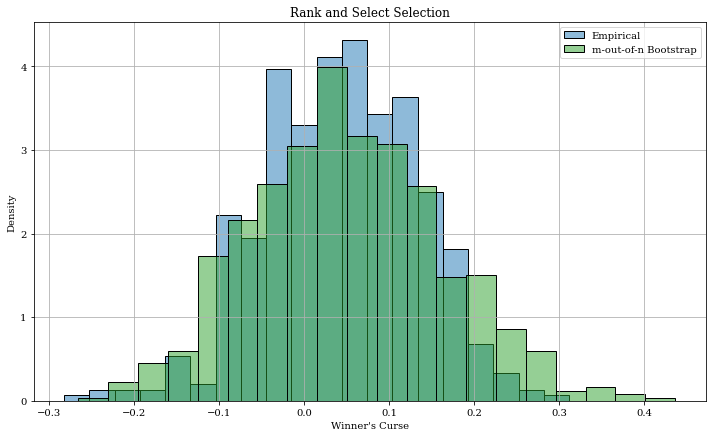

In [19]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [20]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


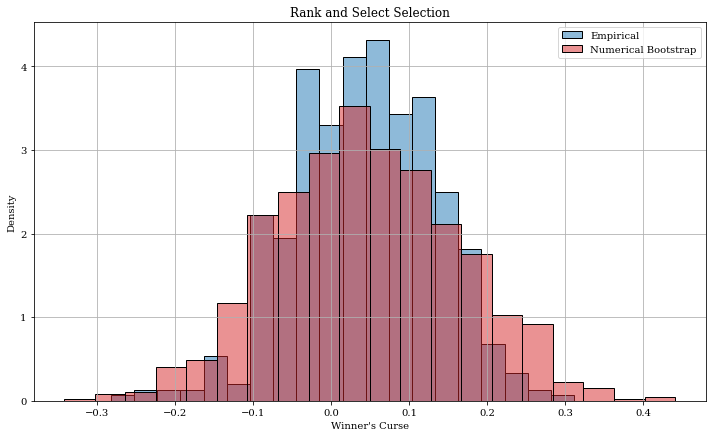

In [21]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [22]:
del dgp, samples, boot_wc_dstn_dict

# Bias Correction

In [23]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'response_type': 'continuous', 
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

In [24]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.8s finished



Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0764 (0.0042)
  - No Correction: 1.1196 (0.0088)
  - Standard Bootstrap: 1.0848 (0.0099)
  - m-out-of-n Bootstrap: 1.0775 (0.0100)
  - Numerical Bootstrap: 1.0758 (0.0102)
  - Empirical Bayes: 1.1196 (0.0088)
  - Conditional SI: 1.0038 (0.0411)
  - Hybrid SI: 1.0580 (0.0146)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 43.15% (9.10%)
  - Standard Bootstrap: 8.42% (9.99%)
  - m-out-of-n Bootstrap: 1.13% (10.03%)
  - Numerical Bootstrap: -0.59% (10.24%)
  - Empirical Bayes: 43.15% (9.10%)
  - Conditional SI: -72.66% (40.48%)
  - Hybrid SI: -18.41% (14.21%)
Median Winner's Curse: 
  - No Correction: 44.99% (9.10%)
  - Standard Bootstrap: 9.37% (9.99%)
  - m-out-of-n Bootstrap: 1.23% (10.03%)
  - Numerical Bootstrap: -0.15% (10.24%)
  - Empirical Bayes: 44.99% (9.10%)
  - Conditional SI: 1.10% (40.48%)
  - Hybrid SI: -0.01% (14.21%)

Sample Splitting: 
  - True Value: 1.0684 (0.0046)
  - Estimated Value: 1.0

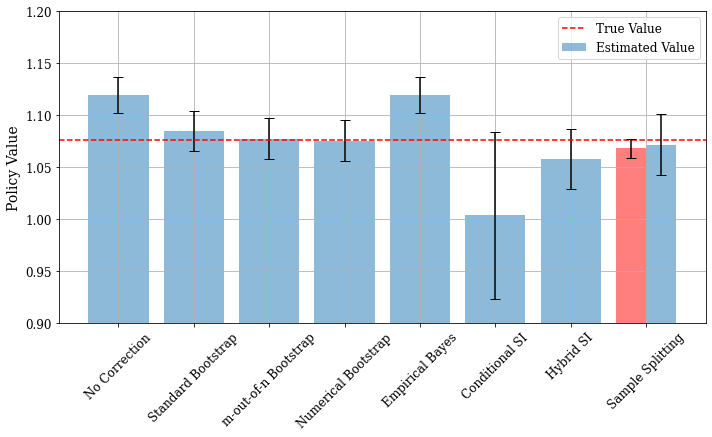

In [25]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Comparative Statics

## Delta Tau

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

### $\tau_1 = 1.0$

In [ ]:
base_tau = 1.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau1_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau1_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.2s finished


In [ ]:
# with open('results/ab_test_delta_tau1.pkl', 'wb') as f:
#     pickle.dump(delta_tau1_result_dict, f)

with open('results/ab_test_delta_tau1.pkl', 'rb') as f:
    delta_tau1_result_dict = pickle.load(f)

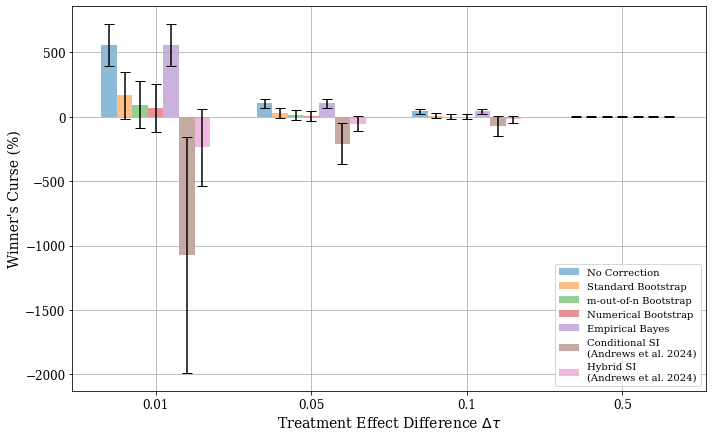

$\Delta\tau=0.01$  \
No Correction                         Mean               557.93   
                                      Median             581.37   
                                      S.E.                83.15   
Standard Bootstrap                    Mean               166.07   
                                      Median             149.28   
                                      S.E.                92.93   
m-out-of-n Bootstrap                  Mean                92.06   
                                      Median              59.35   
                                      S.E.                92.85   
Numerical Bootstrap                   Mean                66.38   
                                      Median              62.25   
                                      S.E.                95.59   
Empirical Bayes                       Mean               557.93   
                                      Median             581.37   
                                      S.E.                83.15   
Conditional SI\n(Andrews et al. 2024) Mean             -1074.33   
                                      Median              73.82   
                                      S.E.               468.06   
Hybrid SI\n(Andrews et al. 2024)      Mean              -237.70   
                                      Median              36.26   
                                      S.E.               151.18   

                                              $\Delta\tau=0.05$  \
No Correction                         Mean               104.41   
                                      Median             111.14   
                                      S.E.                16.99   
Standard Bootstrap                    Mean                28.27   
                                      Median              25.23   
                                      S.E.                18.92   
m-out-of-n Bootstrap                  Mean                13.49   
                                      Median               9.82   
                                      S.E.                18.91   
Numerical Bootstrap                   Mean                 8.69   
                                      Median               4.59   
                                      S.E.                19.44   
Empirical Bayes                       Mean               104.41   
                                      Median             111.14   
                                      S.E.                16.99   
Conditional SI\n(Andrews et al. 2024) Mean              -207.95   
                                      Median               5.99   
                                      S.E.                81.55   
Hybrid SI\n(Andrews et al. 2024)      Mean               -53.33   
                                      Median               3.86   
                                      S.E.                30.71   

                                              $\Delta\tau=0.1$  \
No Correction                         Mean               43.15   
                                      Median             44.99   
                                      S.E.                9.10   
Standard Bootstrap                    Mean                8.42   
                                      Median              9.37   
                                      S.E.                9.99   
m-out-of-n Bootstrap                  Mean                1.13   
                                      Median              1.23   
                                      S.E.               10.03   
Numerical Bootstrap                   Mean               -0.59   
                                      Median             -0.15   
                                      S.E.               10.24   
Empirical Bayes                       Mean               43.15   
                                      Median             44.99   
                                      S.E.                9.10   
Conditional SI\n(Andrews et al. 2024) Me

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[delta_tau]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[delta_tau][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\Delta\\tau={delta_tau: .2f}$' for delta_tau in delta_tau_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & $\Delta\tau= 0.01$ & $\Delta\tau= 0.05$ & $\Delta\tau= 0.10$ & $\Delta\tau= 0.50$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$557.93\%^{***}$\\ ($83.15\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$104.41\%^{***}$\\ ($16.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.15\%^{***}$\\ ($9.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.02\%$\\ ($2.02\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$166.07\%^{*}$\\ ($92.93\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$28.27\%$\\ ($18.92\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.42\%$\\ ($9.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.34\%$\\ ($2.07\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$92.06\%$\\ ($92.85\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$13.49\%$\\ ($18.91\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.13\%$\\ ($10.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.61\%$\\ ($2.08\%$)\end{tabular} \

### $\tau_1 = 2.0$

In [ ]:
base_tau = 2.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau2_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau2_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.3s finished


In [ ]:
with open('results/ab_test_delta_tau2.pkl', 'wb') as f:
    pickle.dump(delta_tau2_result_dict, f)

with open('results/ab_test_delta_tau2.pkl', 'rb') as f:
    delta_tau2_result_dict = pickle.load(f)

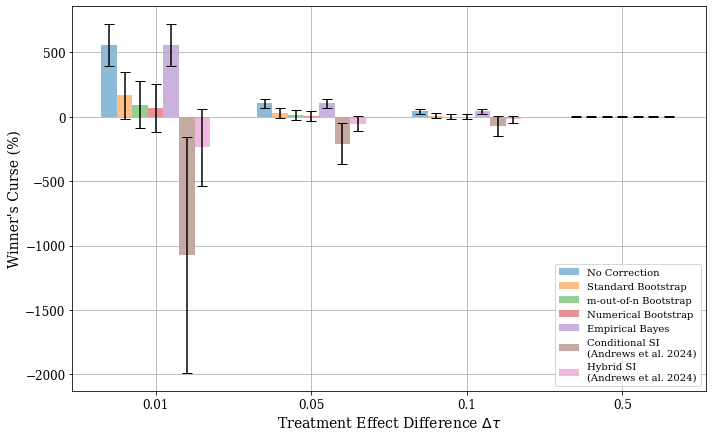

$\Delta\tau=0.01$  \
No Correction                         Mean               557.93   
                                      Median             581.37   
                                      S.E.                83.15   
Standard Bootstrap                    Mean               166.07   
                                      Median             149.28   
                                      S.E.                92.93   
m-out-of-n Bootstrap                  Mean                92.06   
                                      Median              59.35   
                                      S.E.                92.85   
Numerical Bootstrap                   Mean                66.38   
                                      Median              62.25   
                                      S.E.                95.59   
Empirical Bayes                       Mean               557.93   
                                      Median             581.37   
                                      S.E.                83.15   
Conditional SI\n(Andrews et al. 2024) Mean             -1074.33   
                                      Median              73.82   
                                      S.E.               468.06   
Hybrid SI\n(Andrews et al. 2024)      Mean              -237.70   
                                      Median              36.26   
                                      S.E.               151.18   

                                              $\Delta\tau=0.05$  \
No Correction                         Mean               104.41   
                                      Median             111.14   
                                      S.E.                16.99   
Standard Bootstrap                    Mean                28.27   
                                      Median              25.23   
                                      S.E.                18.92   
m-out-of-n Bootstrap                  Mean                13.49   
                                      Median               9.82   
                                      S.E.                18.91   
Numerical Bootstrap                   Mean                 8.69   
                                      Median               4.59   
                                      S.E.                19.44   
Empirical Bayes                       Mean               104.41   
                                      Median             111.14   
                                      S.E.                16.99   
Conditional SI\n(Andrews et al. 2024) Mean              -207.95   
                                      Median               5.99   
                                      S.E.                81.55   
Hybrid SI\n(Andrews et al. 2024)      Mean               -53.30   
                                      Median               3.86   
                                      S.E.                30.71   

                                              $\Delta\tau=0.1$  \
No Correction                         Mean               43.15   
                                      Median             44.99   
                                      S.E.                9.10   
Standard Bootstrap                    Mean                8.42   
                                      Median              9.37   
                                      S.E.                9.99   
m-out-of-n Bootstrap                  Mean                1.13   
                                      Median              1.23   
                                      S.E.               10.03   
Numerical Bootstrap                   Mean               -0.59   
                                      Median             -0.15   
                                      S.E.               10.24   
Empirical Bayes                       Mean               43.15   
                                      Median             44.99   
                                      S.E.                9.10   
Conditional SI\n(Andrews et al. 2024) Me

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau2_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau2_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[delta_tau]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[delta_tau][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\Delta\\tau={delta_tau: .2f}$' for delta_tau in delta_tau_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & $\Delta\tau= 0.01$ & $\Delta\tau= 0.05$ & $\Delta\tau= 0.10$ & $\Delta\tau= 0.50$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$557.93\%^{***}$\\ ($83.15\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$104.41\%^{***}$\\ ($16.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.15\%^{***}$\\ ($9.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.02\%$\\ ($2.02\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$166.07\%^{*}$\\ ($92.93\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$28.27\%$\\ ($18.92\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.42\%$\\ ($9.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.34\%$\\ ($2.07\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$92.06\%$\\ ($92.85\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$13.49\%$\\ ($18.91\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.13\%$\\ ($10.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.61\%$\\ ($2.08\%$)\end{tabular} \

## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [ ]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True, truncate_lb=-3.0, truncate_ub=3.0
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   14.2s finished


In [ ]:
# with open('results/ab_test_sample_size.pkl', 'wb') as f:
#     pickle.dump(sample_size_result_dict, f)

with open('results/ab_test_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

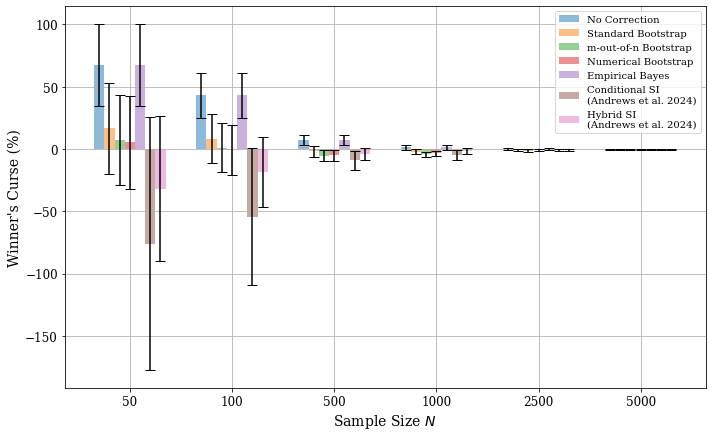

$N=50$  $N=100$  $N=500$  \
No Correction                         Mean     67.62    43.15     7.60   
                                      Median   71.96    44.99     7.73   
                                      S.E.     16.81     9.10     2.01   
Standard Bootstrap                    Mean     16.62     8.42    -1.65   
                                      Median   20.49     9.37     1.75   
                                      S.E.     18.56     9.99     2.20   
m-out-of-n Bootstrap                  Mean      7.21     1.13    -5.31   
                                      Median   10.34     1.23    -2.90   
                                      S.E.     18.55    10.03     2.24   
Numerical Bootstrap                   Mean      5.46    -0.59    -5.09   
                                      Median    6.64    -0.15    -1.69   
                                      S.E.     19.00    10.24     2.29   
Empirical Bayes                       Mean     67.62    43.15     7.60   
                                      Median   71.96    44.99     7.73   
                                      S.E.     16.81     9.10     2.01   
Conditional SI\n(Andrews et al. 2024) Mean    -76.10   -54.16    -9.09   
                                      Median    9.31     1.99     1.49   
                                      S.E.     51.80    28.16     3.73   
Hybrid SI\n(Andrews et al. 2024)      Mean    -31.72   -18.41    -4.14   
                                      Median    4.09    -0.01     1.45   
                                      S.E.     29.66    14.21     2.51   

                                              $N=1000$  $N=2500$  $N=5000$  
No Correction                         Mean        1.50     -0.22     -0.27  
                                      Median      3.15     -0.17     -1.03  
                                      S.E.        0.96      0.41      0.19  
Standard Bootstrap                    Mean       -1.96     -0.61     -0.29  
                                      Median     -0.50     -0.39     -1.18  
                                      S.E.        1.04      0.43      0.19  
m-out-of-n Bootstrap                  Mean       -4.18     -1.11     -0.30  
                                      Median     -2.67     -0.71     -1.07  
                                      S.E.        1.07      0.44      0.20  
Numerical Bootstrap                   Mean       -3.26     -0.87     -0.39  
                                      Median     -1.60     -0.16     -1.05  
                                      S.E.        1.09      0.43      0.19  
Empirical Bayes                       Mean        1.50     -0.22     -0.27  
                                      Median      3.15     -0.17     -1.03  
                                      S.E.        0.96      0.41      0.19  
Conditional SI\n(Andrews et al. 2024) Mean       -4.50     -0.37     -0.27  
                                      Median      1.79     -0.17     -1.03  
                                      S.E.        2.08      0.42      0.19  
Hybrid SI\n(Andrews et al. 2024)      Mean       -1.53     -0.37     -0.27  
                                      Median      1.85     -0.17     -1.03  
                                      S.E.        1.12      0.42      0.19

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$67.62\%^{***}$\\ ($16.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.15\%^{***}$\\ ($9.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.60\%^{***}$\\ ($2.01\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.50\%$\\ ($0.96\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.22\%$\\ ($0.41\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.27\%$\\ ($0.19\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$16.62\%$\\ ($18.56\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.42\%$\\ ($9.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-1.65\%$\\ ($2.20\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-1.96\%^{*}$\\ ($1.04\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.61\%$\\ ($0.43\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.29\%$\\ ($0.19\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$

## Response STD

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

response_std_list = [0.5, 1, 2, 3, 4, 5]

In [ ]:
response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nResponse Standard Deviation = {response_std}')
    
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Response Standard Deviation = 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 2
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.3s finished


In [ ]:
# with open('results/ab_test_response_std.pkl', 'wb') as f:
#     pickle.dump(response_std_result_dict, f)

with open('results/ab_test_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

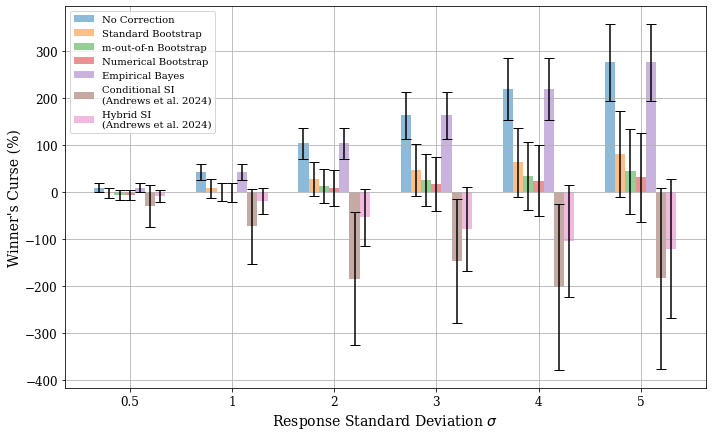

$\sigma=0.5$  $\sigma=1$  \
No Correction                         Mean            9.72       43.15   
                                      Median          8.71       44.99   
                                      S.E.            4.83        9.10   
Standard Bootstrap                    Mean           -2.25        8.42   
                                      Median         -2.79        9.37   
                                      S.E.            5.29        9.99   
m-out-of-n Bootstrap                  Mean           -5.39        1.13   
                                      Median         -7.35        1.23   
                                      S.E.            5.35       10.03   
Numerical Bootstrap                   Mean           -5.42       -0.59   
                                      Median         -6.46       -0.15   
                                      S.E.            5.42       10.24   
Empirical Bayes                       Mean            9.72       43.15   
                                      Median          8.71       44.99   
                                      S.E.            4.83        9.10   
Conditional SI\n(Andrews et al. 2024) Mean          -29.00      -72.66   
                                      Median         -3.18        1.10   
                                      S.E.           23.00       40.48   
Hybrid SI\n(Andrews et al. 2024)      Mean           -7.48      -18.41   
                                      Median         -2.34       -0.01   
                                      S.E.            6.43       14.21   

                                              $\sigma=2$  $\sigma=3$  \
No Correction                         Mean        104.41      163.63   
                                      Median      111.14      173.55   
                                      S.E.         16.99       25.20   
Standard Bootstrap                    Mean         28.27       47.59   
                                      Median       25.23       42.55   
                                      S.E.         18.92       28.11   
m-out-of-n Bootstrap                  Mean         13.49       25.35   
                                      Median        9.82       15.17   
                                      S.E.         18.91       28.09   
Numerical Bootstrap                   Mean          8.69       17.91   
                                      Median        4.59        9.30   
                                      S.E.         19.44       28.89   
Empirical Bayes                       Mean        104.41      163.63   
                                      Median      111.14      173.55   
                                      S.E.         16.99       25.20   
Conditional SI\n(Andrews et al. 2024) Mean       -183.80     -146.01   
                                      Median        6.27       22.27   
                                      S.E.         72.34       66.86   
Hybrid SI\n(Andrews et al. 2024)      Mean        -53.02      -78.04   
                                      Median        3.86       -8.18   
                                      S.E.         30.70       45.76   

                                              $\sigma=4$  $\sigma=5$  
No Correction                         Mean        219.91      276.59  
                                      Median      232.55      290.69  
                                      S.E.         33.47       41.72  
Standard Bootstrap                    Mean         64.15       81.42  
                                      Median       56.20       71.37  
                                      S.E.         37.38       46.62  
m-out-of-n Bootstrap                  Mean         34.52       44.26  
                                      Median       21.54       27.28  
                                      S.E.         37.34       46.56  
Numerical Bootstrap                   Mean         24.48       31.58  
                                      Median       

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[response_std]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[response_std][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\sigma={response_std}$' for response_std in response_std_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $\sigma=0.5$ & $\sigma=1$ & $\sigma=2$ & $\sigma=3$ & $\sigma=4$ & $\sigma=5$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$9.72\%^{**}$\\ ($4.83\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.15\%^{***}$\\ ($9.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$104.41\%^{***}$\\ ($16.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$163.63\%^{***}$\\ ($25.20\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$219.91\%^{***}$\\ ($33.47\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$276.59\%^{***}$\\ ($41.72\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$-2.25\%$\\ ($5.29\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.42\%$\\ ($9.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$28.27\%$\\ ($18.92\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$47.59\%^{*}$\\ ($28.11\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$64.15\%^{*}$\\ ($37.38\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$81.42\%^{*}$\\ ($46.62\%$)\end{tabular} 

## $\Delta\tau / \sigma$

In [37]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 5000, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 5000, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 5000, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

# ratio_list = [0.01, 0.1, 0.5, 1, 2]
ratio_list = [0.1]

samp_vol_list = [1, 2, 3]


In [ ]:
ratio_result_dict = {}

for ratio in ratio_list:
    for samp_vol in samp_vol_list:
        delta_tau = round(samp_vol * ratio, 2)
        print(f'\nRatio = {ratio}; Sampling Volatility = {samp_vol}; Delta tau= {delta_tau}')

        response_vol = np.sqrt(data_params['sample_size'] / 2) * samp_vol

        dgp_params['base_effects'] = [PointMass(1), PointMass(1 + delta_tau)]
        dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_vol), UnivariateGaussian(0, std=response_vol)]

        result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )

        ratio_result_dict[(delta_tau, samp_vol, ratio)] = rct.calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )


Ratio = 0.1; Sampling Volatility = 1; Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   24.5s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 0.1; Sampling Volatility = 2; Delta tau= 0.2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   24.9s


In [ ]:
# with open('results/ab_test_ratio.pkl', 'wb') as f:
#     pickle.dump(ratio_result_dict, f)

# with open('results/ab_test_ratio.pkl', 'rb') as f:
#     ratio_result_dict = pickle.load(f)

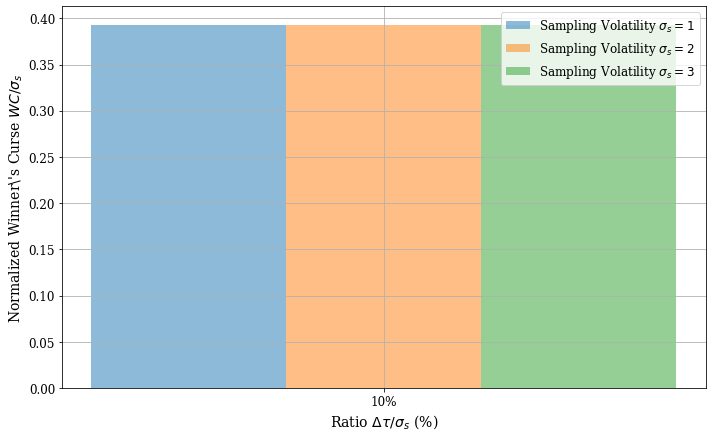

0.1  \
                                             $(\Delta\tau, \sigma_s) = (0.1, 1)$   
No Correction                         Mean                                0.3932   
                                      Median                              0.4111   
                                      S.E.                                0.0588   
Standard Bootstrap                    Mean                                0.1164   
                                      Median                              0.1048   
                                      S.E.                                0.0658   
m-out-of-n Bootstrap                  Mean                                0.0640   
                                      Median                              0.0403   
                                      S.E.                                0.0657   
Numerical Bootstrap                   Mean                                0.0459   
                                      Median                              0.0394   
                                      S.E.                                0.0677   
Empirical Bayes                       Mean                                0.3931   
                                      Median                              0.4111   
                                      S.E.                                0.0588   
Conditional SI\n(Andrews et al. 2024) Mean                               -0.1056   
                                      Median                              0.0948   
                                      S.E.                                0.1119   
Hybrid SI\n(Andrews et al. 2024)      Mean                               -0.1735   
                                      Median                              0.0322   
                                      S.E.                                0.1074   

                                                                                  \
                                             $(\Delta\tau, \sigma_s) = (0.2, 2)$   
No Correction                         Mean                                0.3932   
                                      Median                              0.4111   
                                      S.E.                                0.1177   
Standard Bootstrap                    Mean                                0.1164   
                                      Median                              0.1048   
                                      S.E.                                0.1315   
m-out-of-n Bootstrap                  Mean                                0.0640   
                                      Median                              0.0403   
                                      S.E.                                0.1314   
Numerical Bootstrap                   Mean                                0.0459   
                                      Median                              0.0394   
                                      S.E.                                0.1353   
Empirical Bayes                       Mean                                0.3930   
                                      Median                              0.4111   
                                      S.E.                                0.1177   
Conditional SI\n(Andrews et al. 2024) Mean                                0.0219   
                                      Median                              0.1620   
                                      S.E.                                0.1860   
Hybrid SI\n(Andrews et al. 2024)      Mean                               -0.1159   
                                      Median                              0.0496   
                                      S.E.                                0.2012   

                                                                                  
                                             $(\Delta\tau, \sigma_s) = (0.3, 3)$  
No Correction                         Mean   

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    data[(delta_tau, samp_vol)]['No Correction'] = {
        'Mean': result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol, 
        'Median': np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']) / samp_vol, 
        'S.E.': result_dict[key][f'{optimizer_key}_nc_wc_se'], 
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        median_wc = np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr']) / samp_vol
        se_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[(delta_tau, samp_vol)][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (ratio, '$(\Delta\tau, \sigma_s) = ({}, {})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[(delta_tau, samp_vol)][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(ratio_list))
bar_width = 0.3 * len(samp_vol_list)

for idx, samp_vol in enumerate(samp_vol_list):
    bar_values = [data[(dt, vol)]['No Correction']['Mean'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]
    bar_errors = [1.96 * data[(dt, vol)]['No Correction']['S.E.'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / len(samp_vol_list) + bar_width / 2 / len(samp_vol_list), 
        bar_values, 
        # yerr=bar_errors, 
        capsize=5, alpha=0.5, width=bar_width / len(samp_vol_list),
        label=r'Sampling Volatility $\sigma_s={}$'.format(samp_vol)
    )

ax.set_xlabel(r'Ratio $\Delta\tau / \sigma_s$ (%)', fontsize=axis_label_size)
ax.set_ylabel(r'Normalized Winner\'s Curse $WC / \sigma_s$', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(ratio_list)), 
    labels=[f'{item:.0%}' for item in ratio_list], 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=tick_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(4)

In [ ]:
print(wc_stats_df[[0.1, 1]].map(lambda x: f'{x:.4f}').style.to_latex())

\begin{tabular}{llllllll}
 &  & \multicolumn{3}{r}{0.100000} & \multicolumn{3}{r}{1.000000} \\
 &  & $(\Delta	au, \sigma_s) = (0.1, 1)$ & $(\Delta	au, \sigma_s) = (0.2, 2)$ & $(\Delta	au, \sigma_s) = (0.30000000000000004, 3)$ & $(\Delta	au, \sigma_s) = (1, 1)$ & $(\Delta	au, \sigma_s) = (2, 2)$ & $(\Delta	au, \sigma_s) = (3, 3)$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 0.3932 & 0.3932 & 0.3932 & 0.2480 & 0.2480 & 0.2480 \\
 & Median & 0.4111 & 0.4111 & 0.4111 & 0.2617 & 0.2617 & 0.2617 \\
 & S.E. & 0.0588 & 0.1177 & 0.1765 & 0.0665 & 0.1331 & 0.1996 \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 0.1164 & 0.1164 & 0.1099 & 0.0312 & 0.0312 & 0.0509 \\
 & Median & 0.1048 & 0.1048 & 0.1043 & 0.0241 & 0.0241 & 0.0510 \\
 & S.E. & 0.0658 & 0.1315 & 0.1886 & 0.0724 & 0.1449 & 0.2014 \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 0.0640 & 0.0640 & 0.0575 & -0.0186 & -0.0186 & 0.0081 \\
 & Median & 0.0403 & 0.0403 & 0.0399 & -0.0251 & -0.0251 & 0.0066 \\
 & S.E. & 0.0657 & 0.1314

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / samp_vol
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[(delta_tau, samp_vol)]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / samp_vol
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[(delta_tau, samp_vol)][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'{ratio:.2f}', '$(\Delta\\tau, \sigma_s) = ({:.2f}, {:.2f})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[(delta_tau, samp_vol)][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['0.10', '1.00']]
print(latex_df.style.to_latex(
    column_format='c' * 2 * 3, 
    hrules=True
))


\begin{tabular}{cccccc}
\toprule
 & \multicolumn{3}{r}{0.10} & \multicolumn{3}{r}{1.00} \\
 & $(\Delta\tau, \sigma_s) = (0.10, 1.00)$ & $(\Delta\tau, \sigma_s) = (0.20, 2.00)$ & $(\Delta\tau, \sigma_s) = (0.30, 3.00)$ & $(\Delta\tau, \sigma_s) = (1.00, 1.00)$ & $(\Delta\tau, \sigma_s) = (2.00, 2.00)$ & $(\Delta\tau, \sigma_s) = (3.00, 3.00)$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.3932^{***}$\\ ($0.0588$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3932^{***}$\\ ($0.0588$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3932^{***}$\\ ($0.0588$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2480^{***}$\\ ($0.0665$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2480^{***}$\\ ($0.0665$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2480^{***}$\\ ($0.0665$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.1164^{*}$\\ ($0.0658$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1164^{*}$\\ ($0.0658$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1099^{*}$\\ ($0.0629

## Noise distribution

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [ ]:
noise_dstn_result_dict = {noise_dstn: None for noise_dstn in noise_dstn_dict.keys()}

for noise_key, noise_dstn in noise_dstn_dict.items():
    print(f'\nNoise Distribution = {noise_key}')
    
    dgp_params['noise_vars'] = [noise_dstn, noise_dstn]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_key] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution = Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished


In [ ]:
# with open('results/ab_test_noise_dstn.pkl', 'wb') as f:
#     pickle.dump(noise_dstn_result_dict, f)

with open('results/ab_test_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

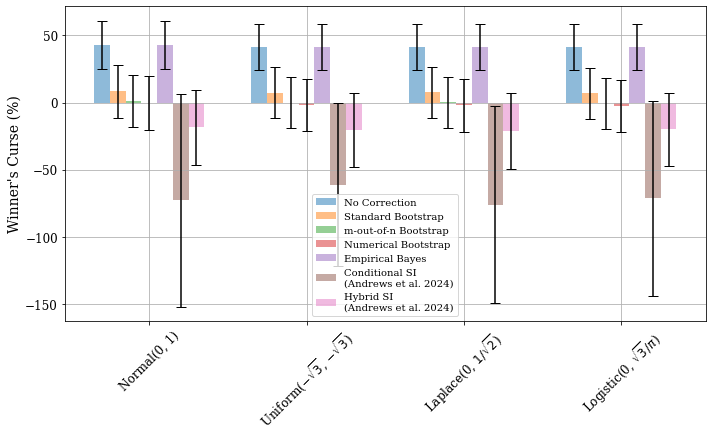

Normal(0, 1)  \
No Correction                         Mean           43.15   
                                      Median         44.99   
                                      S.E.            9.10   
Standard Bootstrap                    Mean            8.42   
                                      Median          9.37   
                                      S.E.            9.99   
m-out-of-n Bootstrap                  Mean            1.13   
                                      Median          1.23   
                                      S.E.           10.03   
Numerical Bootstrap                   Mean           -0.59   
                                      Median         -0.15   
                                      S.E.           10.24   
Empirical Bayes                       Mean           43.15   
                                      Median         44.99   
                                      S.E.            9.10   
Conditional SI\n(Andrews et al. 2024) Mean          -72.66   
                                      Median          1.10   
                                      S.E.           40.48   
Hybrid SI\n(Andrews et al. 2024)      Mean          -18.41   
                                      Median         -0.01   
                                      S.E.           14.21   

                                              Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction                         Mean                                41.52   
                                      Median                              39.93   
                                      S.E.                                 8.83   
Standard Bootstrap                    Mean                                 7.23   
                                      Median                               8.74   
                                      S.E.                                 9.71   
m-out-of-n Bootstrap                  Mean                                -0.13   
                                      Median                               1.53   
                                      S.E.                                 9.72   
Numerical Bootstrap                   Mean                                -1.97   
                                      Median                              -1.15   
                                      S.E.                                 9.94   
Empirical Bayes                       Mean                                41.52   
                                      Median                              39.93   
                                      S.E.                                 8.83   
Conditional SI\n(Andrews et al. 2024) Mean                               -61.35   
                                      Median                              -3.90   
                                      S.E.                                30.99   
Hybrid SI\n(Andrews et al. 2024)      Mean                               -20.63   
                                      Median                              -3.69   
                                      S.E.                                14.03   

                                              Laplace(0, $1/\sqrt{2}$)  \
No Correction                         Mean                       41.66   
                                      Median                     37.57   
                                      S.E.                        8.77   
Standard Bootstrap                    Mean                        7.53   
                                      Median                      6.01   
                                      S.E.                        9.75   
m-out-of-n Bootstrap                  Mean                        0.23   
                                      Median                      1.53   
                                      S.E.                        9.76   
Numerical Bootstrap                   Mean                       -1.97   
                                      Me

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[noise_dstn]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[noise_dstn][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = list(noise_dstn_dict.keys())
print(latex_df.style.to_latex(
    column_format='c' * (len(noise_dstn_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & Normal(0, 1) & Uniform($-\sqrt{3}$, $-\sqrt{3}$) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$43.15\%^{***}$\\ ($9.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$41.52\%^{***}$\\ ($8.83\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$41.66\%^{***}$\\ ($8.77\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$41.09\%^{***}$\\ ($8.72\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$8.42\%$\\ ($9.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.23\%$\\ ($9.71\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.53\%$\\ ($9.75\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$6.86\%$\\ ($9.69\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.13\%$\\ ($10.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.13\%$\\ ($9.72\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.23\%$\\ ($9.76\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.50\%$\\ ($9.70\%$)

# Bernoulli Response

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [ ]:
bernoulli_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

bernoulli_te_result_dict = {bernoulli_te: None for bernoulli_te in bernoulli_te_list}

for te_tuple in bernoulli_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


In [ ]:
with open('results/ab_test_bernoulli_delta_tau.pkl', 'wb') as f:
    pickle.dump(bernoulli_te_result_dict, f)

with open('results/ab_test_bernoulli_delta_tau.pkl', 'rb') as f:
    bernoulli_te_result_dict = pickle.load(f)

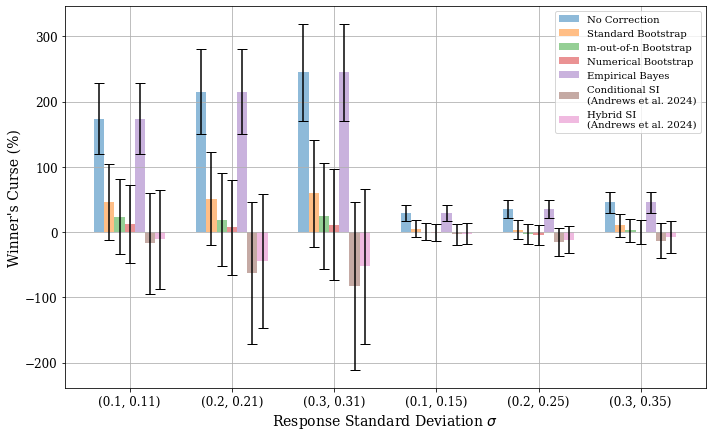

$\Delta\tau = 0.01$  \
                                             $(\tau_1, \tau_2)$ = (0.1, 0.11)   
No Correction                         Mean                             173.99   
                                      Median                           159.98   
                                      S.E.                              27.61   
Standard Bootstrap                    Mean                              45.72   
                                      Median                            28.69   
                                      S.E.                              29.83   
m-out-of-n Bootstrap                  Mean                              23.81   
                                      Median                             2.03   
                                      S.E.                              29.66   
Numerical Bootstrap                   Mean                              12.84   
                                      Median                           -15.47   
                                      S.E.                              30.54   
Empirical Bayes                       Mean                             173.99   
                                      Median                           159.98   
                                      S.E.                              27.61   
Conditional SI\n(Andrews et al. 2024) Mean                             -17.30   
                                      Median                            23.59   
                                      S.E.                              39.60   
Hybrid SI\n(Andrews et al. 2024)      Mean                             -11.00   
                                      Median                            23.59   
                                      S.E.                              38.86   

                                                                               \
                                             $(\tau_1, \tau_2)$ = (0.2, 0.21)   
No Correction                         Mean                             214.95   
                                      Median                           223.59   
                                      S.E.                              33.30   
Standard Bootstrap                    Mean                              51.15   
                                      Median                            28.89   
                                      S.E.                              36.40   
m-out-of-n Bootstrap                  Mean                              19.23   
                                      Median                            -7.77   
                                      S.E.                              36.04   
Numerical Bootstrap                   Mean                               7.51   
                                      Median                           -16.21   
                                      S.E.                              37.09   
Empirical Bayes                       Mean                             214.95   
                                      Median                           223.59   
                                      S.E.                              33.30   
Conditional SI\n(Andrews et al. 2024) Mean                             -62.92   
                                      Median                            23.59   
                                      S.E.                              55.47   
Hybrid SI\n(Andrews et al. 2024)      Mean                             -43.71   
                                      Median                            23.59   
                                      S.E.                              52.41   

                                                                               \
                                             $(\tau_1, \tau_2)$ = (0.3, 0.31)   
No Correction                         Mean                             245.04   
                                      Median                           223.59   
      

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(bernoulli_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in bernoulli_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in bernoulli_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(bernoulli_te_list)), labels=bernoulli_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['$\Delta\\tau = 0.01$', '$\Delta\\tau = 0.05$']]
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & \multicolumn{3}{r}{$\Delta\tau = 0.01$} & \multicolumn{3}{r}{$\Delta\tau = 0.05$} \\
 & $(\tau_1, \tau_2)$ = (0.1, 0.11) & $(\tau_1, \tau_2)$ = (0.2, 0.21) & $(\tau_1, \tau_2)$ = (0.3, 0.31) & $(\tau_1, \tau_2)$ = (0.1, 0.15) & $(\tau_1, \tau_2)$ = (0.2, 0.25) & $(\tau_1, \tau_2)$ = (0.3, 0.35) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$173.99\%^{***}$\\ ($27.61$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$214.95\%^{***}$\\ ($33.30$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$245.04\%^{***}$\\ ($37.88$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$29.61\%^{***}$\\ ($6.11$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$35.53\%^{***}$\\ ($7.16$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$45.59\%^{***}$\\ ($8.30$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$45.72\%$\\ ($29.83$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$51.15\%$\\ ($36.40$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$59.40\%$\\ ($41.94$)\%\en

## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'response_type': 'bernoulli',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [50, 100, 500, 1000, 2500, 5000]

In [ ]:
bernoulli_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/stats/_distn_infrastructure.py:2093: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/iamsikun/Desktop/Research/winners-curse/core/selective_inference.py:71: RuntimeWarning: invalid value encountered in divide
  abs_t = np.abs(xi_arr) / std_arr  # Broadcasting over variances
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.1s
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/stats/_distn_infrastructure.py:2093: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/iamsikun/Desktop/Research/winners-curse/core/selective_inference.py:71: RuntimeWarning: invalid value encountered in divide
  abs_t = np.abs(xi_arr) / std_arr  # Broadcasting over variances
[Parallel(n_j


Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 500
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   14.0s finished


In [ ]:
# with open('results/ab_test_bernoulli_sample_size.pkl', 'wb') as f:
#     pickle.dump(bernoulli_sample_size_result_dict, f)

with open('results/ab_test_bernoulli_sample_size.pkl', 'rb') as f:
    bernoulli_sample_size_result_dict = pickle.load(f)

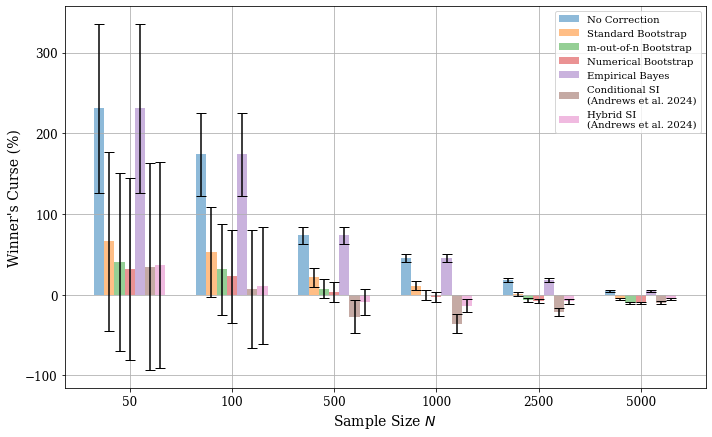

$N=50$  $N=100$  $N=500$  \
No Correction                         Mean    231.20   174.00    73.52   
                                      Median  200.00   200.00    60.00   
                                      S.E.     53.42    26.47     5.46   
Standard Bootstrap                    Mean     66.10    53.01    21.99   
                                      Median   29.20    19.10    10.50   
                                      S.E.     56.78    28.70     5.97   
m-out-of-n Bootstrap                  Mean     40.47    31.55     7.63   
                                      Median    8.24    -0.35    -4.55   
                                      S.E.     56.10    28.71     6.00   
Numerical Bootstrap                   Mean     31.54    22.95     3.64   
                                      Median   -6.93   -13.56    -9.22   
                                      S.E.     57.59    29.54     6.16   
Empirical Bayes                       Mean    231.20   174.00    73.52   
                                      Median  200.00   200.00    60.00   
                                      S.E.     53.42    26.47     5.46   
Conditional SI\n(Andrews et al. 2024) Mean     34.50     6.91   -26.99   
                                      Median   27.37    21.72    14.28   
                                      S.E.     65.44    37.41    10.25   
Hybrid SI\n(Andrews et al. 2024)      Mean     37.21    11.40    -8.67   
                                      Median   28.44    24.33    14.58   
                                      S.E.     65.21    36.89     8.40   

                                              $N=1000$  $N=2500$  $N=5000$  
No Correction                         Mean       45.48     18.79      4.42  
                                      Median     50.00     20.00      2.00  
                                      S.E.        2.74      1.20      0.63  
Standard Bootstrap                    Mean       11.23      0.81     -4.85  
                                      Median      8.49      1.28     -5.33  
                                      S.E.        2.99      1.30      0.68  
m-out-of-n Bootstrap                  Mean        0.07     -6.65    -10.04  
                                      Median     -2.41     -5.67    -10.33  
                                      S.E.        3.02      1.32      0.70  
Numerical Bootstrap                   Mean       -3.17     -7.72     -9.85  
                                      Median     -7.95     -5.03    -10.08  
                                      S.E.        3.13      1.36      0.72  
Empirical Bayes                       Mean       45.48     18.79      4.42  
                                      Median     50.00     20.00      2.00  
                                      S.E.        2.74      1.20      0.63  
Conditional SI\n(Andrews et al. 2024) Mean      -35.83    -21.53     -9.71  
                                      Median     -0.16      3.65     -2.41  
                                      S.E.        6.05      2.50      1.01  
Hybrid SI\n(Andrews et al. 2024)      Mean      -13.40     -7.81     -5.42  
                                      Median     -0.07      3.74     -2.21  
                                      S.E.        4.30      1.61      0.78

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$231.20\%^{***}$\\ ($53.42\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$174.00\%^{***}$\\ ($26.47\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$73.52\%^{***}$\\ ($5.46\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$45.48\%^{***}$\\ ($2.74\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$18.79\%^{***}$\\ ($1.20\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$4.42\%^{***}$\\ ($0.63\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$66.10\%$\\ ($56.78\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$53.01\%^{*}$\\ ($28.70\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$21.99\%^{***}$\\ ($5.97\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$11.23\%^{***}$\\ ($2.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.81\%$\\ ($1.30\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-4.85\%^{***}$\\ ($0.68\%$)\end{tabular} \\
m-out-of-n

# Logit Response

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'logit', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [ ]:
logit_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

logit_te_result_dict = {logit_te: None for logit_te in logit_te_list}

for te_tuple in logit_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [PointMass(te_tuple[0]),PointMass(te_tuple[1])]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   41.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   47.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.2, 0.21)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   14.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   34.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   39.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.31)
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   35.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   41.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.2, 0.25)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   34.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   40.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.35)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   34.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   40.0s finished


In [ ]:
with open('results/ab_test_logit_delta_tau.pkl', 'wb') as f:
    pickle.dump(logit_te_result_dict, f)

with open('results/ab_test_logit_delta_tau.pkl', 'rb') as f:
    logit_te_result_dict = pickle.load(f)

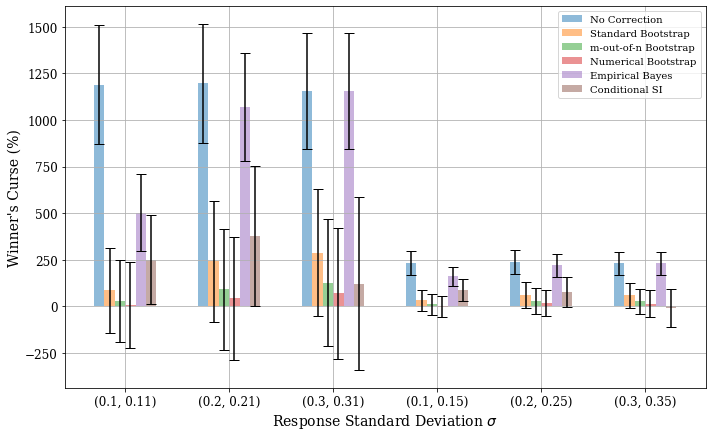

$\Delta\tau = 0.01$  \
                            $(\tau_1, \tau_2)$ = (0.1, 0.11)   
No Correction        Mean                            1189.36   
                     Median                          1311.62   
                     S.E.                             162.86   
Standard Bootstrap   Mean                              86.10   
                     Median                           150.82   
                     S.E.                             115.90   
m-out-of-n Bootstrap Mean                              31.18   
                     Median                            99.39   
                     S.E.                             112.39   
Numerical Bootstrap  Mean                               6.78   
                     Median                            83.26   
                     S.E.                             116.99   
Empirical Bayes      Mean                             502.83   
                     Median                           603.42   
                     S.E.                             105.47   
Conditional SI       Mean                             251.29   
                     Median                           409.02   
                     S.E.                             121.18   

                                                              \
                            $(\tau_1, \tau_2)$ = (0.2, 0.21)   
No Correction        Mean                            1197.56   
                     Median                          1177.73   
                     S.E.                             162.47   
Standard Bootstrap   Mean                             240.84   
                     Median                           284.38   
                     S.E.                             165.80   
m-out-of-n Bootstrap Mean                              92.34   
                     Median                           123.66   
                     S.E.                             166.01   
Numerical Bootstrap  Mean                              43.39   
                     Median                            42.39   
                     S.E.                             167.88   
Empirical Bayes      Mean                            1069.05   
                     Median                          1127.73   
                     S.E.                             148.59   
Conditional SI       Mean                             375.87   
                     Median                           555.36   
                     S.E.                             192.01   

                                                              \
                            $(\tau_1, \tau_2)$ = (0.3, 0.31)   
No Correction        Mean                            1155.45   
                     Median                          1054.65   
                     S.E.                             158.40   
Standard Bootstrap   Mean                             288.69   
                     Median                           234.35   
                     S.E.                             174.84   
m-out-of-n Bootstrap Mean                             127.39   
                     Median                            50.60   
                     S.E.                             173.78   
Numerical Bootstrap  Mean                              70.95   
                     Median                           -18.61   
                     S.E.                             179.62   
Empirical Bayes      Mean                            1155.35   
                     Median                          1054.65   
                     S.E.                             158.41   
Conditional SI       Mean                             122.19   
                     Median                           319.00   
                     S.E.                             237.68   

                                         $\Delta\tau = 0.05$  \
                            $(\tau_1, \tau_2)$ = (0.1, 0.15)   
No Correction        Mean                             234.63   
      

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(logit_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in logit_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in logit_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(logit_te_list)), labels=logit_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['$\Delta\\tau = 0.01$', '$\Delta\\tau = 0.05$']]
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & \multicolumn{3}{r}{$\Delta\tau = 0.01$} & \multicolumn{3}{r}{$\Delta\tau = 0.05$} \\
 & $(\tau_1, \tau_2)$ = (0.1, 0.11) & $(\tau_1, \tau_2)$ = (0.2, 0.21) & $(\tau_1, \tau_2)$ = (0.3, 0.31) & $(\tau_1, \tau_2)$ = (0.1, 0.15) & $(\tau_1, \tau_2)$ = (0.2, 0.25) & $(\tau_1, \tau_2)$ = (0.3, 0.35) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$1189.36\%^{***}$\\ ($162.86$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1197.56\%^{***}$\\ ($162.47$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1155.45\%^{***}$\\ ($158.40$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$234.63\%^{***}$\\ ($32.74$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$235.64\%^{***}$\\ ($32.88$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$231.63\%^{***}$\\ ($31.67$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$86.10\%$\\ ($115.90$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$240.84\%$\\ ($165.80$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$288.69\%^{

## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'response_type': 'logit',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'empirical_bayes': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

sample_size_list = [50, 100, 500, 1000, 2500, 5000]

In [ ]:
logit_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   39.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   45.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   38.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   44.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 500
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   45.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.8min finished


In [ ]:
with open('results/ab_test_logit_sample_size.pkl', 'wb') as f:
    pickle.dump(logit_sample_size_result_dict, f)

with open('results/ab_test_logit_sample_size.pkl', 'rb') as f:
    logit_sample_size_result_dict = pickle.load(f)

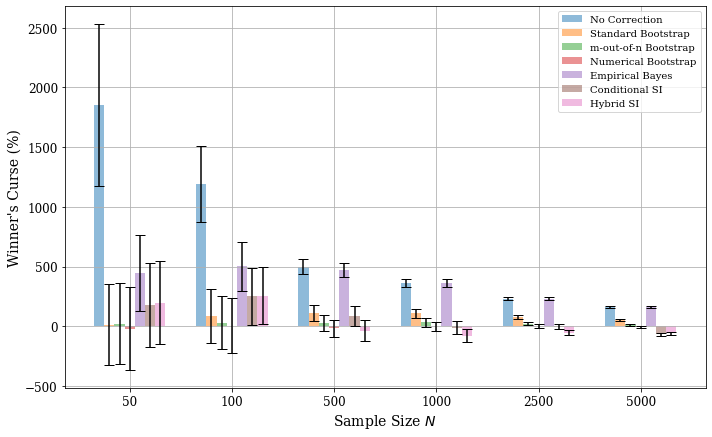

$N=50$  $N=100$  $N=500$  $N=1000$  $N=2500$  \
No Correction        Mean    1853.37  1189.36   501.17    365.86    233.61   
                     Median  2127.73  1311.62   442.50    362.10    213.89   
                     S.E.     346.91   162.86    32.20     16.81      6.58   
Standard Bootstrap   Mean      14.01    86.10   113.71    109.29     77.84   
                     Median    20.76   150.82    70.52    111.72     53.50   
                     S.E.     172.10   115.90    34.25     18.26      7.29   
m-out-of-n Bootstrap Mean      22.87    31.18    26.19     34.27     24.46   
                     Median    -1.48    99.39    -3.51     39.10      0.16   
                     S.E.     173.66   112.39    34.78     18.36      7.34   
Numerical Bootstrap  Mean     -20.80     6.78   -14.06      1.63      2.86   
                     Median    -1.02    83.26   -50.71     -9.37    -23.72   
                     S.E.     177.46   116.99    36.09     19.25      7.70   
Empirical Bayes      Mean     446.95   502.83   469.67    361.60    233.61   
                     Median   503.42   603.42   442.50    362.10    213.89   
                     S.E.     163.26   105.47    30.56     16.57      6.58   
Conditional SI       Mean     177.86   251.29    85.41     -9.78     -1.48   
                     Median   253.09   409.02   130.55     87.52     78.07   
                     S.E.     178.15   121.18    42.73     26.34     11.55   
Hybrid SI            Mean     199.35   258.53   -34.78    -78.51    -50.85   
                     Median   416.25   416.64    44.79     21.87     45.85   
                     S.E.     177.45   120.68    46.30     27.23     11.67   

                             $N=5000$  
No Correction        Mean      161.86  
                     Median    161.30  
                     S.E.        3.44  
Standard Bootstrap   Mean       50.64  
                     Median     39.29  
                     S.E.        3.82  
m-out-of-n Bootstrap Mean       10.72  
                     Median      2.14  
                     S.E.        3.83  
Numerical Bootstrap  Mean       -5.67  
                     Median    -16.13  
                     S.E.        4.04  
Empirical Bayes      Mean      161.86  
                     Median    161.30  
                     S.E.        3.44  
Conditional SI       Mean      -67.35  
                     Median     19.08  
                     S.E.        7.04  
Hybrid SI            Mean      -57.84  
                     Median     -9.32  
                     S.E.        5.92

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$1853.37\%^{***}$\\ ($346.91\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1189.36\%^{***}$\\ ($162.86\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$501.17\%^{***}$\\ ($32.20\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$365.86\%^{***}$\\ ($16.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$233.61\%^{***}$\\ ($6.58\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$161.86\%^{***}$\\ ($3.44\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$14.01\%$\\ ($172.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$86.10\%$\\ ($115.90\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$113.71\%^{***}$\\ ($34.25\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$109.29\%^{***}$\\ ($18.26\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$77.84\%^{***}$\\ ($7.29\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$50.64\%^{***}$\\ ($3.82\%$)\end{ta

# Sketch